In [2]:
from pathlib import Path
import shutil
import time

from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

In [3]:
RAW_DIR = Path("../data/raw/plantvillage_dataset/color")
SPLIT_DIR = Path("../data/splits")

SEED = 42

print("Raw dataset exists:", RAW_DIR.exists())
print("Split directory:", SPLIT_DIR)

Raw dataset exists: True
Split directory: ../data/splits


In [4]:
class_dirs = [d for d in RAW_DIR.iterdir() if d.is_dir()]

total_images = sum(
    sum(1 for f in class_dir.iterdir() if f.is_file())
    for class_dir in class_dirs
)

print("Number of classes:", len(class_dirs))
print("Total images:", total_images)

Number of classes: 38
Total images: 54305


In [5]:
# Remove old split folder if it exists
if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

# Create main split folders
for split in ["train", "val", "test"]:
    (SPLIT_DIR / split).mkdir(parents=True, exist_ok=True)

with tqdm(
    total=total_images,
    desc="Creating dataset split",
    unit="image"
) as progress:

    for class_dir in class_dirs:

        images = [f for f in class_dir.iterdir() if f.is_file()]

        # 70% training, 30% remaining
        train_images, remaining_images = train_test_split(
            images,
            test_size=0.30,
            random_state=SEED
        )

        # Remaining 30% → 15% validation + 15% test
        val_images, test_images = train_test_split(
            remaining_images,
            test_size=0.50,
            random_state=SEED
        )

        split_data = {
            "train": train_images,
            "val": val_images,
            "test": test_images
        }

        for split, image_list in split_data.items():

            destination = SPLIT_DIR / split / class_dir.name
            destination.mkdir(parents=True, exist_ok=True)

            for image_path in image_list:
                shutil.copy2(image_path, destination / image_path.name)
                progress.update(1)

print("Dataset split completed successfully!")

Creating dataset split: 100%|██████████| 54305/54305 [00:35<00:00, 1540.51image/s]

Dataset split completed successfully!


In [6]:
split_counts = {}

for split in ["train", "val", "test"]:
    split_path = SPLIT_DIR / split
    
    count = sum(
        1
        for class_dir in split_path.iterdir()
        if class_dir.is_dir()
        for f in class_dir.iterdir()
        if f.is_file()
    )
    
    split_counts[split] = count

print("Train images:", split_counts["train"])
print("Validation images:", split_counts["val"])
print("Test images:", split_counts["test"])
print("Total:", sum(split_counts.values()))

Train images: 37998
Validation images: 8145
Test images: 8162
Total: 54305


In [7]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 8

train_dir = SPLIT_DIR / "train"
val_dir = SPLIT_DIR / "val"
test_dir = SPLIT_DIR / "test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("\nNumber of classes:", num_classes)
print("First 5 classes:", class_names[:5])

I0000 00:00:1788532460.420074    3474 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788532461.038447    3474 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788532463.711501    3474 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Found 37998 files belonging to 38 classes.


I0000 00:00:1788532472.255436    3474 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 8145 files belonging to 38 classes.
Found 8162 files belonging to 38 classes.

Number of classes: 38
First 5 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Dataset pipeline optimized.")

Dataset pipeline optimized.


In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

print("Data augmentation ready.")

Data augmentation ready.


In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=IMG_SIZE + (3,)),

    data_augmentation,
    tf.keras.layers.Rescaling(1.0 / 255),

    # Block 1
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Block 2
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Block 3
    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Classification head
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,558 (451.40 KB)

 Trainable params: 115,110 (449.65 KB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [12]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_DIR / "best_custom_cnn.keras"),
        monitor="val_loss",
        save_best_only=True
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

print("Callbacks ready.")

Callbacks ready.


In [13]:
import tensorflow as tf

print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20


/home/piyus/projects/plant-disease-classification-cnn/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788532847.942405    4888 cuda_dnn.cc:461] Loaded cuDNN version 92501


4750/4750 ━━━━━━━━━━━━━━━━━━━━ 595s 123ms/step - accuracy: 0.5447 - loss: 1.5788 - val_accuracy: 0.1675 - val_loss: 8.4840 - learning_rate: 0.0010
Epoch 2/20
4750/4750 ━━━━━━━━━━━━━━━━━━━━ 570s 120ms/step - accuracy: 0.7060 - loss: 0.9538 - val_accuracy: 0.7494 - val_loss: 0.8353 - learning_rate: 0.0010
Epoch 3/20
4750/4750 ━━━━━━━━━━━━━━━━━━━━ 545s 115ms/step - accuracy: 0.7713 - loss: 0.7269 - val_accuracy: 0.7901 - val_loss: 0.6736 - learning_rate: 0.0010
Epoch 4/20
4750/4750 ━━━━━━━━━━━━━━━━━━━━ 573s 121ms/step - accuracy: 0.8133 - loss: 0.5907 - val_accuracy: 0.7629 - val_loss: 0.9430 - learning_rate: 0.0010
Epoch 5/20
4750/4750 ━━━━━━━━━━━━━━━━━━━━ 571s 120ms/step - accuracy: 0.8360 - loss: 0.5146 - val_accuracy: 0.7562 - val_loss: 0.9641 - learning_rate: 0.0010
Epoch 6/20
4750/4750 ━━━━━━━━━━━━━━━━━━━━ 560s 118ms/step - accuracy: 0.8736 - loss: 0.3945 - val_accuracy: 0.8266 - val_loss: 0.7087 - learning_rate: 5.0000e-04
Epoch 7/20
4750/4750 ━━━━━━━━━━━━━━━━━━━━ 558s 118ms/step -

In [15]:
MODEL_DIR = Path("../models")

best_model = tf.keras.models.load_model(
    MODEL_DIR / "best_custom_cnn.keras"
)

print("Best model loaded successfully!")

Best model loaded successfully!


In [16]:
test_loss, test_accuracy = best_model.evaluate(
    test_ds,
    verbose=1
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy (%): {test_accuracy * 100:.2f}%")

1021/1021 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - accuracy: 0.9340 - loss: 0.2327

Test Loss: 0.2327
Test Accuracy: 0.9340
Test Accuracy (%): 93.40%


In [17]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = best_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("True labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)
print("Number of predictions:", len(y_pred))

True labels shape: (8162,)
Predicted labels shape: (8162,)
Number of predictions: 8162


In [23]:
from sklearn.metrics import classification_report

# Add class index before class name
class_names_with_index = [
    f"{i}: {class_name}"
    for i, class_name in enumerate(class_names)
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names_with_index,
        digits=4
    )
)

                                                       precision    recall  f1-score   support

                                0: Apple___Apple_scab     0.9659    0.8947    0.9290        95
                                 1: Apple___Black_rot     0.9300    0.9894    0.9588        94
                          2: Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        42
                                   3: Apple___healthy     0.8373    1.0000    0.9114       247
                               4: Blueberry___healthy     1.0000    0.9779    0.9888       226
          5: Cherry_(including_sour)___Powdery_mildew     1.0000    0.9430    0.9707       158
                 6: Cherry_(including_sour)___healthy     0.9843    0.9690    0.9766       129
7: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9828    0.7403    0.8444        77
                       8: Corn_(maize)___Common_rust_     1.0000    1.0000    1.0000       179
               9: Corn_(maize)___Northern_Leaf_Bl

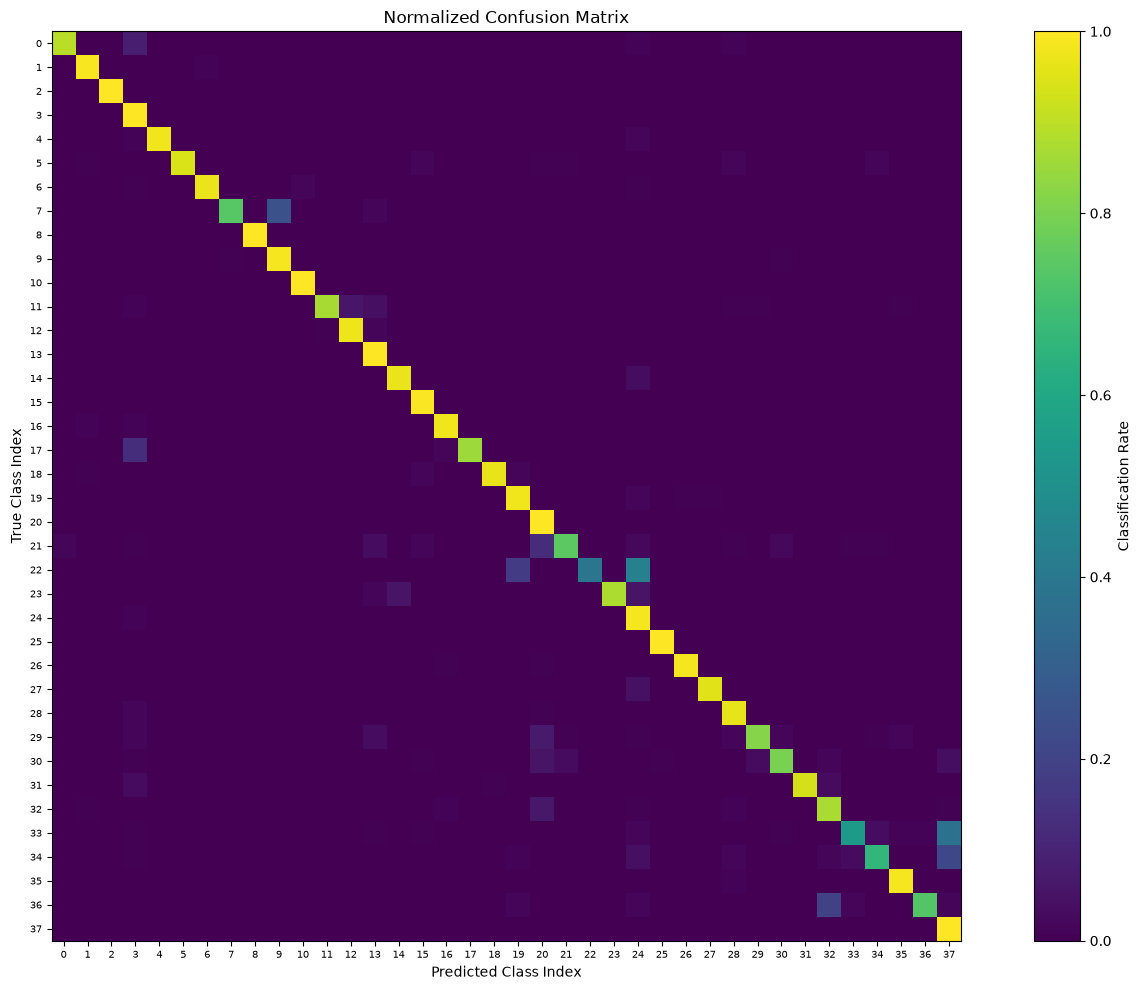

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize by true class (row-wise)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Create compact plot
plt.figure(figsize=(15, 10))

plt.imshow(
    cm_normalized,
    interpolation="nearest",
    vmin=0,
    vmax=1
)

plt.title("Normalized Confusion Matrix")
plt.colorbar(label="Classification Rate")

plt.xlabel("Predicted Class Index")
plt.ylabel("True Class Index")

# Show class indices
class_indices = np.arange(len(class_names))
plt.xticks(class_indices, class_indices, fontsize=7)
plt.yticks(class_indices, class_indices, fontsize=7)

plt.tight_layout()
plt.show()

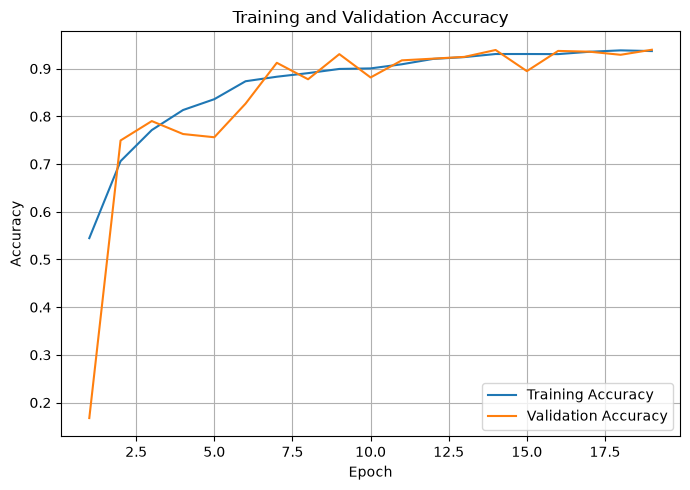

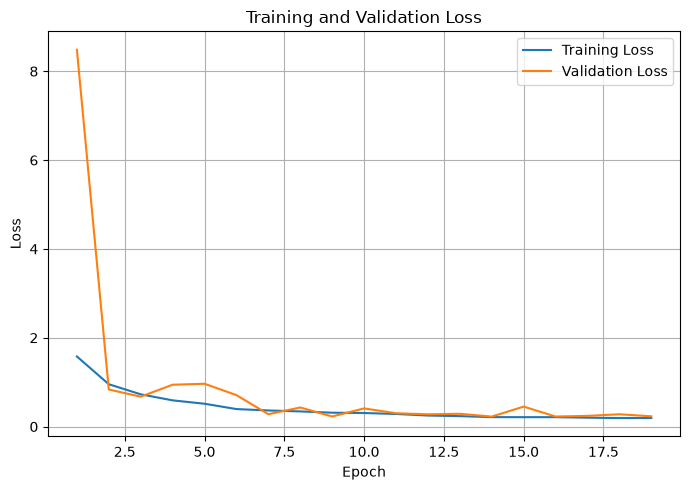

In [26]:
import matplotlib.pyplot as plt

# Get training history
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(train_accuracy) + 1)

# Accuracy plot
plt.figure(figsize=(7, 5))

plt.plot(epochs_range, train_accuracy, label="Training Accuracy")
plt.plot(epochs_range, val_accuracy, label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Loss plot
plt.figure(figsize=(7, 5))

plt.plot(epochs_range, train_loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

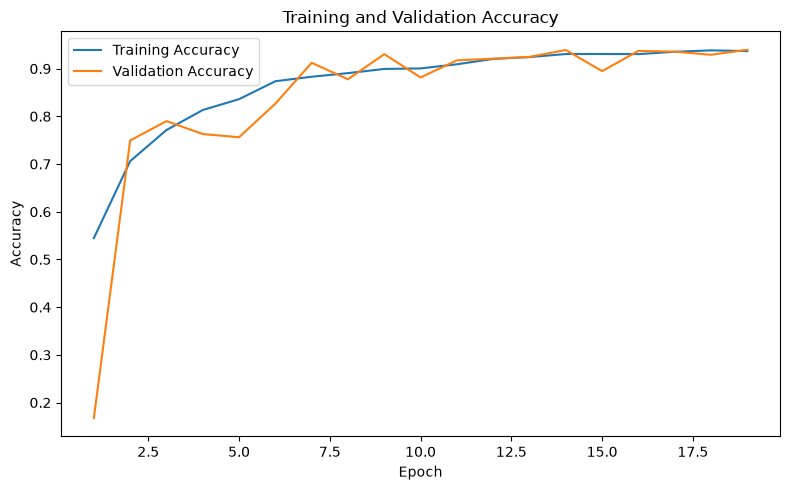

In [ ]:
epochs = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.tight_layout()

plt.show()